왼쪽의 지문영상을 오른쪽 영상과 같이 개선해보세요.  
수업시간에 배운 방법을 기본적으로 적용해보고,   
더 좋은 방법이 있으면 해당 방법도 적용하고 결과를 분석해보세요.  

In [7]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt
import sys

In [8]:
img = cv.imread('img/finger.jpg')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

In [12]:
blur = cv.GaussianBlur(gray, (5, 5), 0)
# blur = cv.GaussianBlur(gray, (9, 9), 0)
combined = cv.hconcat([gray, blur])
combined_small = cv.resize(combined, None, fx=0.4, fy=0.4)

cv.imshow('가우시안', combined_small)

cv.waitKey()
cv.destroyAllWindows()

![image.png](img/save/fg1.png)

가우시안으로 효과는 분명 존재하지만 완전하지 않았다.

Morphology

침식 연산을 통해서 이미지의 객체를 줄이고 축소 시키면 된다. 


![image.png](img/save/잡음제거.png)

In [16]:
kernel = np.ones((2,2), np.uint8)
erosion = cv.erode(gray, kernel, iterations=1)

combined = cv.hconcat([gray, erosion])
combined_small = cv.resize(combined, None, fx=0.4, fy=0.4)

cv.imshow('침식', combined_small)

cv.waitKey()
cv.destroyAllWindows()

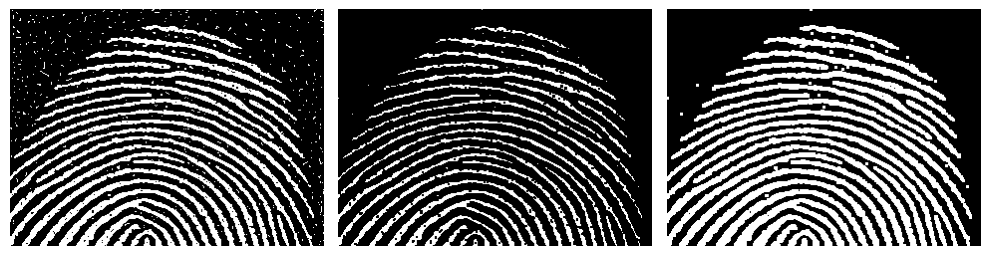

In [32]:

kernel2 = np.ones((2,2), np.uint8)
kernel3 = np.ones((3,3), np.uint8)
kernel5 = np.ones((5,5), np.uint8)

erosion = cv.erode(gray, kernel2, iterations=1)
dilation = cv.dilate(erosion, kernel3, iterations=1)
 

images = [gray, erosion, dilation]

plt.figure(figsize=(10,5))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

커널3 이상은 특징 소실의 선이었기에 2로 해보았는데 (커널2가 말이 되는건가 싶긴하지만) 실제로 선이 유지되는 선으로 지울 수 있었다. 
침식을 사용한 이후 팽창을 통해서 지문 선 속의 픽셀을 채워주었다. 

In [25]:
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])


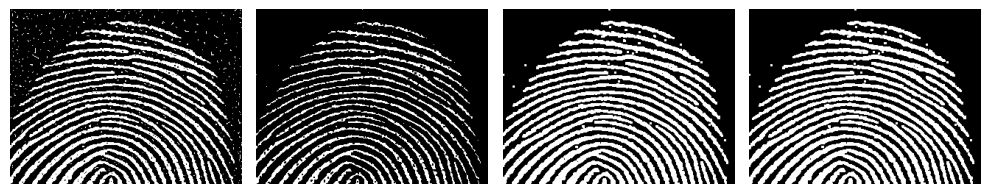

In [ ]:

kernel2 = np.ones((2,2), np.uint8)
kernel3 = np.ones((3,3), np.uint8)
kernel5 = np.ones((5,5), np.uint8)

erosion = cv.erode(gray, kernel2, iterations=1)
dilation = cv.dilate(erosion, kernel3, iterations=1)
sharpen = cv.filter2D(dilation, -1, sharpen_kernel)

images = [gray, erosion, dilation, sharpen]

plt.figure(figsize=(10,5))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

샤프닝까지 사용해서 뭉게진 테두리를 정리해보았으나 이름과 다르게 선의 가장자리가 엄청 유의미하다고 보긴 어렵고   
대신 지문 선 경계 속에 여전히 남아있던 검은 픽셀을 잡는데 더 유용했다. 
생각해보면 그게 맞는 것 같기도 하다